<a href="https://colab.research.google.com/github/kmillaevelyn/data-science-portfolio/blob/main/02-dashboards-visualizacao/analise-grafos-clustering/clustering-noticias-tfidf-kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#UPLOAD FILE AND LOAD FILE INTO VARIABLE
from google.colab import files
import pandas as pd
try:
  df = pd.read_csv("Base_dia_3.csv")
except:
  uploaded_files = files.upload()
  df = pd.read_csv(next(iter(uploaded_files)))
print(df.head())

                                                text
0  Em 1998, quando João Havelange deixou a presid...
1  Em 1998, quando João Havelange deixou a presid...
2  REBECCA R. RUIZ JULIET MACUR IAN AUSTEN DO "NE...
3  Se você tivesse que adivinhar o emprego de Min...
4  Campeão brasileiro, Cuca não é mais técnico do...


## Preprocessing the text data

I will now clean the text data by performing the following steps:
1.  Remove punctuation.
2.  Convert text to lowercase.
3.  Remove numbers.
4.  Remove extra spaces.

In [ ]:
import re

# Remove punctuation
df['text_cleaned'] = df['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

# Convert to lowercase
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: x.lower())

# Remove numbers
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\d+', '', x))

# Remove extra spaces
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

# display(df[['text', 'text_cleaned']].head())

## Tokenization

Next, we'll break down the cleaned text into individual words or 'tokens'. This is a crucial step for preparing the text for the Bag-of-Words model. We'll use NLTK for this.

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Download the 'punkt' tokenizer
nltk.download('punkt')
nltk.download('punkt_tab')

# Apply word tokenization
df['tokens'] = df['text_cleaned'].apply(word_tokenize)

display(df[['text_cleaned', 'tokens']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text_cleaned,tokens
0,em quando joão havelange deixou a presidência ...,"[em, quando, joão, havelange, deixou, a, presi..."
1,em quando joão havelange deixou a presidência ...,"[em, quando, joão, havelange, deixou, a, presi..."
2,rebecca r ruiz juliet macur ian austen do new ...,"[rebecca, r, ruiz, juliet, macur, ian, austen,..."
3,se você tivesse que adivinhar o emprego de min...,"[se, você, tivesse, que, adivinhar, o, emprego..."
4,campeão brasileiro cuca não é mais técnico do ...,"[campeão, brasileiro, cuca, não, é, mais, técn..."


## Stopword Removal

Now, we'll remove common words (stopwords) that don't add much meaning to the text, such as 'de', 'a', 'o', etc. This helps in focusing on more significant words for analysis.

In [ ]:
from nltk.corpus import stopwords

# Download the 'stopwords' corpus
nltk.download('stopwords')

# Define Portuguese stopwords
stop_words = set(stopwords.words('portuguese'))

# Function to remove stopwords
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Apply stopword removal
df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)

display(df[['tokens', 'tokens_no_stopwords']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,tokens,tokens_no_stopwords
0,"[em, quando, joão, havelange, deixou, a, presi...","[joão, havelange, deixou, presidência, fifa, f..."
1,"[em, quando, joão, havelange, deixou, a, presi...","[joão, havelange, deixou, presidência, fifa, f..."
2,"[rebecca, r, ruiz, juliet, macur, ian, austen,...","[rebecca, r, ruiz, juliet, macur, ian, austen,..."
3,"[se, você, tivesse, que, adivinhar, o, emprego...","[adivinhar, emprego, mino, raiola, base, aparê..."
4,"[campeão, brasileiro, cuca, não, é, mais, técn...","[campeão, brasileiro, cuca, técnico, palmeiras..."


## Lemmatization with spaCy

Lemmatization is the process of reducing inflected words to their base or dictionary form (lemma). For example, 'running' becomes 'run'. This step helps in standardizing words for better analysis. We will use the `spaCy` library for this task, specifically a Portuguese model.

In [ ]:
# Import sys to check for installed modules (though try-except is more direct)
import sys

# Check if spaCy is installed and install if not
try:
    import spacy
    print("spaCy is already installed.")
except ImportError:
    print("spaCy is not installed. Installing now...")
    !pip install spacy
    import spacy # Re-import after installation to make it available in the session

# Download Portuguese language model for spaCy if not already downloaded
try:
    # Attempt to load the model; if it's not found, an OSError is raised
    spacy.load('pt_core_news_sm')
    print("Portuguese spaCy model 'pt_core_news_sm' is already installed.")
except OSError:
    print("Portuguese spaCy model 'pt_core_news_sm' not found. Downloading now...")
    !python -m spacy download pt_core_news_sm
    # After successful download, load the model to ensure it's ready for use
    spacy.load('pt_core_news_sm')

print("spaCy and 'pt_core_news_sm' are ready.")

spaCy is already installed.
Portuguese spaCy model 'pt_core_news_sm' not found. Downloading now...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 68.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy and 'pt_core_news_sm' are ready.


In [ ]:
import spacy
from datetime import datetime

now = datetime.now()
print("Carregando biblioteca spaCy... Hora:", now)
# Load the Portuguese language model
try:
    nlp = spacy.load('pt_core_news_sm')
except OSError:
    print("Downloading spaCy model 'pt_core_news_sm'...")
    !python -m spacy download pt_core_news_sm
    nlp = spacy.load('pt_core_news_sm')

now = datetime.now()
print("Iniciando Lemantização... Hora:", now)
# Function to lemmatize tokens
def lemmatize_text(tokens):
    doc = nlp(" ".join(tokens)) # spaCy expects a string, so join tokens
    return [token.lemma_ for token in doc]

# Apply lemmatization
df['lemmas'] = df['tokens_no_stopwords'].apply(lemmatize_text)

now = datetime.now()
print("Reaplicando lower case... Hora:", now)

# Convert to lowercase AGAIN (now iterating through each lemma in the list)
df['lemmas'] = df['lemmas'].apply(lambda x: [lemma.lower() for lemma in x])
now = datetime.now()
print("Tudo pronto! Hora:", now)

display(df[['tokens_no_stopwords', 'lemmas']].head())

Carregando biblioteca spaCy... Hora: 2026-07-01 16:52:28.091500
Iniciando Lemantização... Hora: 2026-07-01 16:52:28.771320
Reaplicando lower case... Hora: 2026-07-01 16:54:16.513269
Tudo pronto! Hora: 2026-07-01 16:54:16.604245


,tokens_no_stopwords,lemmas
0,"[joão, havelange, deixou, presidência, fifa, f...","[joão, havelange, deixar, presidência, fifa, f..."
1,"[joão, havelange, deixou, presidência, fifa, f...","[joão, havelange, deixar, presidência, fifa, f..."
2,"[rebecca, r, ruiz, juliet, macur, ian, austen,...","[rebecca, r, ruiz, juliet, macur, ian, austen,..."
3,"[adivinhar, emprego, mino, raiola, base, aparê...","[adivinhar, emprego, mino, raiola, base, aparê..."
4,"[campeão, brasileiro, cuca, técnico, palmeiras...","[campeão, brasileiro, cucar, técnico, palmeira..."


## Bag-of-Words (BoW) e TF-IDF

Agora, transformaremos o texto lematizado em representações numéricas usando duas técnicas comuns:

1.  **Bag-of-Words (BoW):** Este modelo representa o texto como uma coleção não ordenada de palavras, ignorando a gramática e até mesmo a ordem das palavras, mas mantendo a multiplicidade. Ele conta a frequência de cada palavra.
2.  **TF-IDF (Term Frequency-Inverse Document Frequency):** Esta técnica reflete a importância de uma palavra para um documento em uma coleção ou corpus. O valor TF-IDF aumenta proporcionalmente ao número de vezes que uma palavra aparece no documento, mas é compensado pela frequência da palavra no corpus, o que ajuda a ajustar o fato de que algumas palavras aparecem com mais frequência em geral.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Join the list of lemmas back into a single string for each document
df['lemmas_str'] = df['lemmas'].apply(lambda x: ' '.join(x))

display(df[['lemmas', 'lemmas_str']].head())

,lemmas,lemmas_str
0,"[joão, havelange, deixar, presidência, fifa, f...",joão havelange deixar presidência fifa folha p...
1,"[joão, havelange, deixar, presidência, fifa, f...",joão havelange deixar presidência fifa folha p...
2,"[rebecca, r, ruiz, juliet, macur, ian, austen,...",rebecca r ruiz juliet macur ian austen new yor...
3,"[adivinhar, emprego, mino, raiola, base, aparê...",adivinhar emprego mino raiola base aparência t...
4,"[campeão, brasileiro, cucar, técnico, palmeira...",campeão brasileiro cucar técnico palmeiras tim...


In [ ]:
# Initialize CountVectorizer for Bag-of-Words
# We don't need to specify stop_words here because they were already removed.
count_vectorizer = CountVectorizer()

# Apply Bag-of-Words to the lemmatized strings
bow_matrix = count_vectorizer.fit_transform(df['lemmas_str'])

# Convert to DataFrame for easier inspection (optional, for display purposes)
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=count_vectorizer.get_feature_names_out())

print("Bag-of-Words Matrix Shape:", bow_matrix.shape)
display(bow_df.head())

Bag-of-Words Matrix Shape: (1500, 36469)


,2e,aa,aaron,aassistir,aazrr,ab,abacate,abacatinho,abacaxi,abadr,...,ôôôôôôtodo,øl,última,último,úmbria,úmer,úmir,único,útero,útil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,6,0,0,0,2,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,8,0,0,0,2,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,6,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,2,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Apply TF-IDF to the lemmatized strings
tfidf_matrix = tfidf_vectorizer.fit_transform(df['lemmas_str'])

# Convert to DataFrame for easier inspection (optional, for display purposes)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
display(tfidf_df.head())

TF-IDF Matrix Shape: (1500, 36469)


,2e,aa,aaron,aassistir,aazrr,ab,abacate,abacatinho,abacaxi,abadr,...,ôôôôôôtodo,øl,última,último,úmbria,úmer,úmir,único,útero,útil
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.012059,0.0,0.0,0.0,0.005319,0.0,0.00484
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.020917,0.0,0.0,0.0,0.006920,0.0,0.00000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.021620,0.0,0.0,0.0,0.004768,0.0,0.00000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.002550,0.0,0.0,0.0,0.006750,0.0,0.00000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.007438,0.0,0.0,0.0,0.000000,0.0,0.00000


## Agrupamento K-means

Agora, aplicaremos o algoritmo de agrupamento K-means à matriz TF-IDF. O K-means é um algoritmo de aprendizado não supervisionado que particiona `n` observações em `k` clusters, onde cada observação pertence ao cluster com o centroide mais próximo, servindo como um protótipo do cluster. Usaremos `n_init='auto'` para garantir uma inicialização robusta dos centroides.

Por enquanto, escolheremos um número arbitrário de clusters (por exemplo, 5). O próximo passo será determinar o número ideal de clusters.

In [ ]:
from sklearn.cluster import KMeans

# NUMBER OF CLUSTERS!!!!
k = 4

# Initialize KMeans model
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')

# Fit the model to the TF-IDF matrix and get cluster assignments
df['cluster'] = kmeans_model.fit_predict(tfidf_matrix)

print(f"Number of documents per cluster for k={k}:")
display(df['cluster'].value_counts().sort_index().to_frame())

display(df.head())

Number of documents per cluster for k=4:


,count
cluster,
0,141
1,407
2,467
3,485


,text,text_cleaned,tokens,tokens_no_stopwords,lemmas,lemmas_str,cluster
0,"Em 1998, quando João Havelange deixou a presid...",em quando joão havelange deixou a presidência ...,"[em, quando, joão, havelange, deixou, a, presi...","[joão, havelange, deixou, presidência, fifa, f...","[joão, havelange, deixar, presidência, fifa, f...",joão havelange deixar presidência fifa folha p...,2
1,"Em 1998, quando João Havelange deixou a presid...",em quando joão havelange deixou a presidência ...,"[em, quando, joão, havelange, deixou, a, presi...","[joão, havelange, deixou, presidência, fifa, f...","[joão, havelange, deixar, presidência, fifa, f...",joão havelange deixar presidência fifa folha p...,2
2,"REBECCA R. RUIZ JULIET MACUR IAN AUSTEN DO ""NE...",rebecca r ruiz juliet macur ian austen do new ...,"[rebecca, r, ruiz, juliet, macur, ian, austen,...","[rebecca, r, ruiz, juliet, macur, ian, austen,...","[rebecca, r, ruiz, juliet, macur, ian, austen,...",rebecca r ruiz juliet macur ian austen new yor...,2
3,Se você tivesse que adivinhar o emprego de Min...,se você tivesse que adivinhar o emprego de min...,"[se, você, tivesse, que, adivinhar, o, emprego...","[adivinhar, emprego, mino, raiola, base, aparê...","[adivinhar, emprego, mino, raiola, base, aparê...",adivinhar emprego mino raiola base aparência t...,2
4,"Campeão brasileiro, Cuca não é mais técnico do...",campeão brasileiro cuca não é mais técnico do ...,"[campeão, brasileiro, cuca, não, é, mais, técn...","[campeão, brasileiro, cuca, técnico, palmeiras...","[campeão, brasileiro, cucar, técnico, palmeira...",campeão brasileiro cucar técnico palmeiras tim...,2


## Encontrando o Número Ótimo de Clusters (Método do Cotovelo)

O Método do Cotovelo é uma heurística usada para determinar o número de clusters em um conjunto de dados. A ideia é executar o agrupamento K-means para uma faixa de valores de `k` e, para cada `k`, calcular a Soma dos Quadrados Dentro do Cluster (WCSS - Within-Cluster Sum of Squares). O WCSS é a soma das distâncias ao quadrado entre cada ponto e o centroide em um cluster. O 'cotovelo' no gráfico do WCSS versus `k` indica o `k` ótimo.

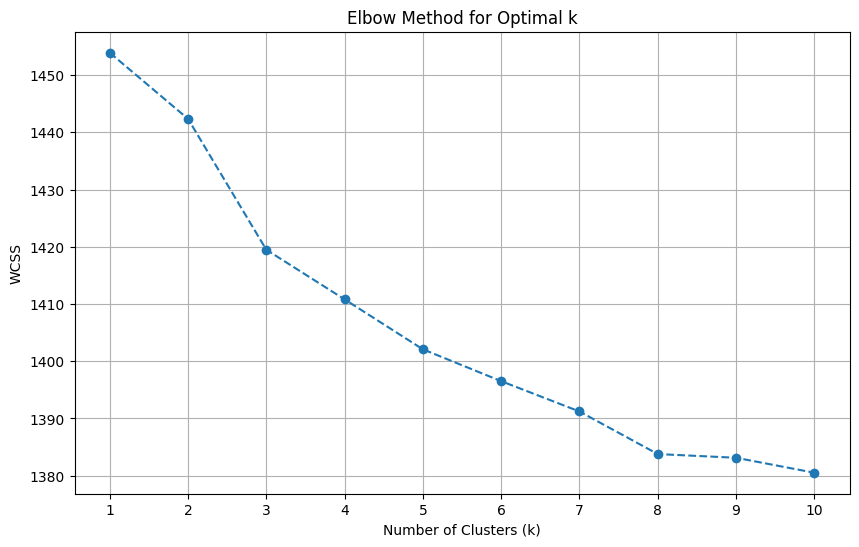

Observe o gráfico para identificar o 'cotovelo', que sugere o número ideal de clusters.


In [ ]:
import matplotlib.pyplot as plt

wcss = []
max_k = 10 # You can adjust this maximum number of clusters to explore

for i in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(tfidf_matrix)
    wcss.append(kmeans.inertia_) # inertia is the WCSS

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, max_k + 1))
plt.grid(True)
plt.show()

print("Observe o gráfico para identificar o 'cotovelo', que sugere o número ideal de clusters.")

## Avaliação do Número Ótimo de Clusters (Silhouette Score)

O Silhouette Score é uma métrica usada para calcular a qualidade dos clusters criados por algoritmos de clustering, como o K-Means. Ele mede o quão parecido um objeto é com seu próprio cluster (coesão) em comparação com outros clusters (separação).

*   **Valores próximos a +1** indicam que as amostras estão bem separadas dos clusters vizinhos.
*   **Valores próximos a 0** indicam que as amostras estão muito próximas do limite de decisão entre dois clusters vizinhos.
*   **Valores próximos a -1** indicam que as amostras podem ter sido atribuídas ao cluster errado.

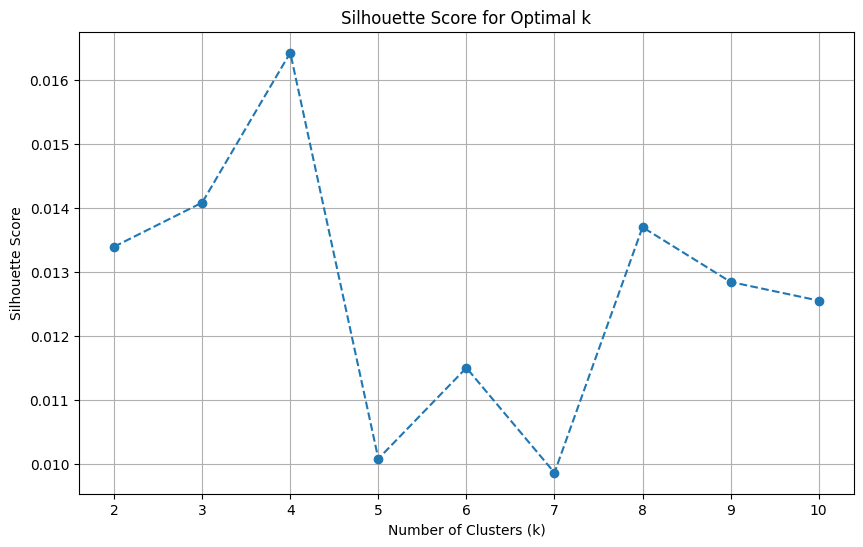

Um score mais alto geralmente indica melhor definição de cluster.


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
max_k = 10 # Should be the same as max_k in the Elbow Method cell

# Note: Silhouette Score requires at least 2 clusters
for i in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans_labels = kmeans.fit_predict(tfidf_matrix)
    score = silhouette_score(tfidf_matrix, kmeans_labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_k + 1))
plt.grid(True)
plt.show()

print("Um score mais alto geralmente indica melhor definição de cluster.")

## Identificação dos Tópicos dos Clusters (para k)

Agora, vamos analisar os termos mais importantes para cada um dos k clusters identificados, apresentando o número de documentos e o total de palavras por cluster em formato de tabela.

In [ ]:
import pandas as pd

# Obter os termos (palavras) do TfidfVectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Obter os centroides dos clusters
# O 'kmeans_model' já foi treinado com o numero escolhido de clusters(k) na célula anterior.
cluster_centroids = kmeans_model.cluster_centers_

# Número de termos principais para exibir por cluster
num_top_words = 30

print(f"Análise detalhada dos {k} clusters:")

# Obter a contagem de documentos por cluster
doc_counts = df['cluster'].value_counts().sort_index()

# Calcular o número total de palavras (lemas) por cluster
total_words_per_cluster = df.groupby('cluster')['lemmas'].apply(lambda x: sum(len(lst) for lst in x))

# Calculate the number of words per document
df['num_words_per_doc'] = df['lemmas'].apply(len)

# Calculate the average number of words per document for each cluster
avg_words_per_doc_per_cluster = df.groupby('cluster')['num_words_per_doc'].mean()

# Calculate the total number of documents overall
total_documents_overall = len(df)

cluster_data = []

for i, centroid in enumerate(cluster_centroids):
    # Obter os índices dos termos com os maiores valores TF-IDF para este cluster
    top_features_indices = centroid.argsort()[-num_top_words:][::-1]

    # Obter os nomes dos termos usando os índices
    top_features = [feature_names[j] for j in top_features_indices]

    cluster_doc_count = doc_counts.get(i, 0)
    percentage_of_documents = (cluster_doc_count / total_documents_overall) * 100 if total_documents_overall > 0 else 0

    cluster_info = {
        'Cluster': i,
        'Número de Documentos': cluster_doc_count,
        'Porcentagem de Documentos do Total': f'{percentage_of_documents:.2f}%',
        'Número Total de Palavras (Lemmas)': total_words_per_cluster.get(i, 0),
        'Média de Palavras por Documento': avg_words_per_doc_per_cluster.get(i, 0),
        f'Top {num_top_words} Termos': ', '.join(top_features)
    }
    cluster_data.append(cluster_info)

# Criar um DataFrame a partir dos dados coletados
clusters_df = pd.DataFrame(cluster_data)

# Exibir o DataFrame
display(clusters_df)

Análise detalhada dos 4 clusters:


,Cluster,Número de Documentos,Porcentagem de Documentos do Total,Número Total de Palavras (Lemmas),Média de Palavras por Documento,Top 30 Termos
0,0,141,9.40%,3816,27.063830,"blog, postr, completo, leio, leia, post, astrô..."
1,1,407,27.13%,59049,145.083538,"restaurante, chef, prato, casa, receita, tel, ..."
2,2,467,31.13%,334703,716.708779,"jogo, clube, jogador, futebol, ir, ano, fazer,..."
3,3,485,32.33%,94683,195.222680,"cientista, poder, estudo, pesquisador, espacia..."
